In [60]:
import chess

import time
from dataclasses import dataclass

from IPython.display import display, clear_output

import matplotlib.pyplot as plt

In [ ]:
class Bot1:
    def __init__(self):
        self.PIECE_VALUE = {
            chess.PAWN: 100,
            chess.KNIGHT: 300,
            chess.BISHOP: 300,
            chess.ROOK: 500,
            chess.QUEEN: 900,
            chess.KING: 0
        }

        self.PST = {
            chess.PAWN: [
                0,   0,   0,   0,   0,   0,   0,   0,
                78,  83,  86,  73, 102,  82,  85,  90,
                7,  29,  21,  44,  40,  31,  44,   7,
                -17,  16,  -2,  15,  14,   0,  15, -13,
                -26,   3,  10,   9,   6,   1,   0, -23,
                -22,   9,   5, -11, -10,  -2,   3, -19,
                -31,   8,  -7, -37, -36, -14,   3, -31,
                0,   0,   0,   0,   0,   0,   0,   0
            ],
            chess.KNIGHT: [
                -66, -53, -75, -75, -10, -55, -58, -70,
                -3,  -6, 100, -36,   4,  62,  -4, -14,
                10,  67,   1,  74,  73,  27,  62,  -2,
                24,  24,  45,  37,  33,  41,  25,  17,
                -1,   5,  31,  21,  22,  35,   2,   0,
                -18,  10,  13,  22,  18,  15,  11, -14,
                -23, -15,   2,   0,   2,   0, -23, -20,
                -74, -23, -26, -24, -19, -35, -22, -69
            ],
            chess.BISHOP: [
                -59, -78, -82, -76, -23,-107, -37, -50,
                -11,  20,  35, -42, -39,  31,   2, -22,
                -9,  39, -32,  41,  52, -10,  28, -14,
                25,  17,  20,  34,  26,  25,  15,  10,
                13,  10,  17,  23,  17,  16,   0,   7,
                14,  25,  24,  15,   8,  25,  20,  15,
                19,  20,  11,   6,   7,   6,  20,  16,
                -7,   2, -15, -12, -14, -15, -10, -10
            ],
            chess.ROOK: [
                35,  29,  33,   4,  37,  33,  56,  50,
                55,  29,  56,  67,  55,  62,  34,  60,
                19,  35,  28,  33,  45,  27,  25,  15,
                0,   5,  16,  13,  18,  -4,  -9,  -6,
                -28, -35, -16, -21, -13, -29, -46, -30,
                -42, -28, -42, -25, -25, -35, -26, -46,
                -53, -38, -31, -26, -29, -43, -44, -53,
                -30, -24, -18,   5,  -2, -18, -31, -32
            ],
            chess.QUEEN: [
                6,   1,  -8,-104,  69,  24,  88,  26,
                14,  32,  60, -10,  20,  76,  57,  24,
                -2,  43,  32,  60,  72,  63,  43,   2,
                1, -16,  22,  17,  25,  20, -13,  -6,
                -14, -15,  -2,  -5,  -1, -10, -20, -22,
                -30,  -6, -13, -11, -16, -11, -16, -27,
                -36, -18,   0, -19, -15, -15, -21, -38,
                -39, -30, -31, -13, -31, -36, -34, -42
            ],
            chess.KING: [
                4,  54,  47, -99, -99,  60,  83, -62,
                -32,  10,  55,  56,  56,  55,  10,   3,
                -62,  12, -57,  44, -67,  28,  37, -31,
                -55,  50,  11,  -4, -19,  13,   0, -49,
                -55, -43, -52, -28, -51, -47,  -8, -50,
                -47, -42, -43, -79, -64, -32, -29, -32,
                -4,   3, -14, -50, -57, -18,  13,   4,
                17,  30,  -3, -14,   6,  -1,  40,  18
            ],
        }

        for piece, table in self.PST.items():
            for i in range(64):
                self.PST[piece][i] += self.PIECE_VALUE[piece]

        self.CHECKMATE_SCORE = 10_000

    def evaluate(self, board: chess.Board) -> int:
        score = 0
        
        if board.turn is chess.BLACK:
            temp_board = board.mirror()
        else:
            temp_board = board
        
        for square, piece in temp_board.piece_map().items():
            if piece.color is chess.WHITE:
                score += self.PST[piece.piece_type][square]
            else:
                score -= self.PST[piece.piece_type][square]
        
        return score

    def move_ordering(self, board: chess.Board):
        def move_score(move: chess.Move):
            score = 0
            
            if board.is_capture(move):
                if board.is_en_passant(move):
                    victim = chess.PAWN
                else:
                    victim = board.piece_at(move.to_square).piece_type
                attacker = board.piece_at(move.from_square).piece_type
                score += self.PIECE_VALUE[victim] * 2 - self.PIECE_VALUE[attacker]
            
            if move.promotion:
                score += self.PIECE_VALUE[move.promotion]
            
            if board.gives_check(move):
                score += 100
            
            return score
        
        return sorted(board.legal_moves, key=move_score)

    def negamax(self, board: chess.Board, ply, max_ply, alpha, beta):
        self.nodes += 1
        
        if board.is_checkmate():
            return -self.CHECKMATE_SCORE + ply, None
        if board.is_stalemate() or board.is_insufficient_material() or board.can_claim_threefold_repetition() or board.is_fifty_moves():
            return 0, None
        
        if ply >= max_ply:
            return self.evaluate(board), None
        
        max_score = float('-inf')
        best_move: chess.Move = None
        
        for move in board.legal_moves:
            board.push(move)
            score, _ = self.negamax(board, ply + 1, max_ply, -beta, -alpha)
            score = -score
            board.pop()
        
            if score > max_score:
                max_score = score
                best_move = move
            
            alpha = max(alpha, score)
            if alpha >= beta:
                break
        
        return max_score, best_move

In [62]:
@dataclass
class Limit:
    time: float = None
    depth: int = None
    nodes: int = None


class Engine:
    def __init__(self):
        self.PIECE_VALUE = {
            chess.PAWN: 100,
            chess.KNIGHT: 300,
            chess.BISHOP: 300,
            chess.ROOK: 500,
            chess.QUEEN: 900,
            chess.KING: 0
        }

        self.CHECKMATE_SCORE = 10_000
    
    def _evaluate(self, board: chess.Board) -> int:
        score = 0
        
        if board.turn is chess.BLACK:
            t_board = board.mirror()
        else:
            t_board = board
        
        for square, piece in t_board.piece_map().items():
            if piece.color is chess.WHITE:
                score += self.PIECE_VALUE[piece.piece_type]
            else:
                score -= self.PIECE_VALUE[piece.piece_type]
        
        return score
    
    def _negamax(self, board: chess.Board, depth: int, alpha: float, beta: float):
        self.nodes += 1
        
        if board.is_checkmate():
            return -self.CHECKMATE_SCORE - depth, None
        if board.is_stalemate() or board.is_insufficient_material() or board.can_claim_threefold_repetition() or board.is_fifty_moves():
            return 0, None
        
        if depth <= 0:
            return self._evaluate(board), None

        best_score = float('-inf')
        best_move = None
        
        for move in board.legal_moves:
            board.push(move)
            score, _ = self._negamax(board, depth - 1, -beta, -alpha)
            score = -score
            board.pop()
            
            if score > best_score:
                best_score = score
                best_move = move
            
            alpha = max(alpha, score)
            if alpha >= beta:
                break
        
        return best_score, best_move
    
    def search(self, board: chess.Board, limit: Limit):
        self.nodes = 0
        
        alpha = float('-inf')
        beta = float('inf')
        
        score, move = self._negamax(board, limit.depth, alpha, beta)
        
        return move, score




In [90]:
fens = ["r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R b KQkq - 3 3",
        "rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3",
        "r3k2r/p3bppp/1p6/2p1Pb2/2P1pB2/1P6/P3BPPP/3RK2R w K - 4 14",
        "rnbqk1nr/pppp1p1p/3b2p1/4p3/4P1Q1/8/PPPP1PPP/RNB1KBNR w KQkq - 6 6"]

In [64]:
board = chess.Board(fens[0])

bot1 = Engine()
bot2 = Bot1()

times_1 = []
times_2 = []
score_1 = []
score_2 = []
nodes_1 = []
nodes_2 = []
moves = []

depth = 4

-504 0.14817070000208332 8598


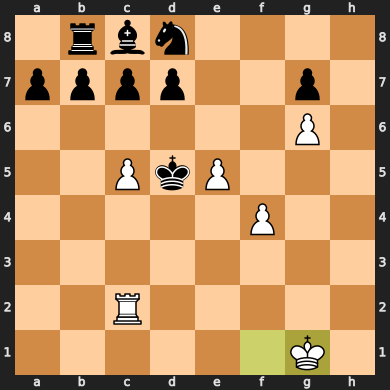

Draw.


In [48]:
while True:
    if board.is_game_over(claim_draw=True):
        break
    
    s = time.perf_counter()
    move, score = bot1.search(board, Limit(depth=depth))
    e = time.perf_counter()
    board.push(move)
    
    moves.append(move)
    times_1.append(e - s)
    score_1.append(score)
    nodes_1.append(bot1.nodes)
    
    clear_output(wait=True)
    print(score, e - s, bot1.nodes)
    display(board)
    
    if board.is_game_over(claim_draw=True):
        break
    
    bot2.nodes = 0
    s = time.perf_counter()
    score, move = bot2.negamax(board, 0, depth, -float('inf'), float('inf'))
    e = time.perf_counter()
    board.push(move)
    
    moves.append(move)
    times_2.append(e - s)
    score_2.append(score)
    nodes_2.append(bot2.nodes)
    
    clear_output(wait=True)
    print(score, e - s, bot2.nodes)
    display(board)

if board.outcome(claim_draw=True).winner is None:
    print('Draw.')
elif board.outcome().winner is True:
    print('Bot1 Win.')
else:
    print('Bot1 Lose.')

9999 0.8173869999991439 2692


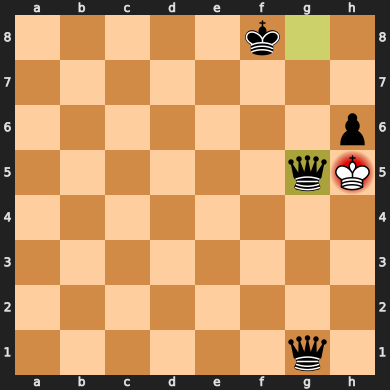

Bot2 Lose.


In [65]:
while True:
    if board.is_game_over(claim_draw=True):
        break
    
    bot2.nodes = 0
    s = time.perf_counter()
    score, move = bot2.negamax(board, 0, depth, -float('inf'), float('inf'))
    e = time.perf_counter()
    board.push(move)
    
    moves.append(move)
    times_2.append(e - s)
    score_2.append(score)
    nodes_2.append(bot2.nodes)
    
    clear_output(wait=True)
    print(score, e - s, bot2.nodes)
    display(board)
    
    if board.is_game_over(claim_draw=True):
            break
    
    s = time.perf_counter()
    move, score = bot1.search(board, Limit(depth=depth))
    e = time.perf_counter()
    board.push(move)
    
    moves.append(move)
    times_1.append(e - s)
    score_1.append(score)
    nodes_1.append(bot1.nodes)
    
    clear_output(wait=True)
    print(score, e - s, bot1.nodes)
    display(board)

if board.outcome(claim_draw=True).winner is None:
    print('Draw.')
elif board.outcome().winner is True:
    print('Bot2 Win.')
else:
    print('Bot2 Lose.')

In [92]:
board = chess.Board(fens[3])

score = 0

samples = 10000

for i in range(samples):
    score = 0

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.outcome(claim_draw=True):
        if board.is_checkmate():
            score = 100
        else:
            score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.outcome():
        if board.is_checkmate():
            score = 100
        else:
            score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.is_game_over(claim_draw=True):
        if board.is_checkmate():
            score = 100
        else:
            score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.is_game_over():
        if board.is_checkmate():
            score = 100
        else:
            score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.is_checkmate():
        score = 100
    if board.is_insufficient_material() or board.is_fifty_moves() or board.can_claim_threefold_repetition() or board.is_stalemate():
        score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.is_checkmate():
        score = 100
    if board.is_insufficient_material() or board.can_claim_draw() or board.is_stalemate():
        score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

times = []
for i in range(samples):
    s = time.perf_counter()
    if board.is_checkmate():
        score = 100
    elif board.is_game_over(claim_draw=True):
        score = 0
    e = time.perf_counter()
    times.append(e - s)
print(sum(times) / len(times))

0.00014630701000969566
3.182229997401009e-06
0.0001497764499981713
3.2863000084034865e-06
0.0001512430900336767
0.0001493746799947985
0.0001531713100070192


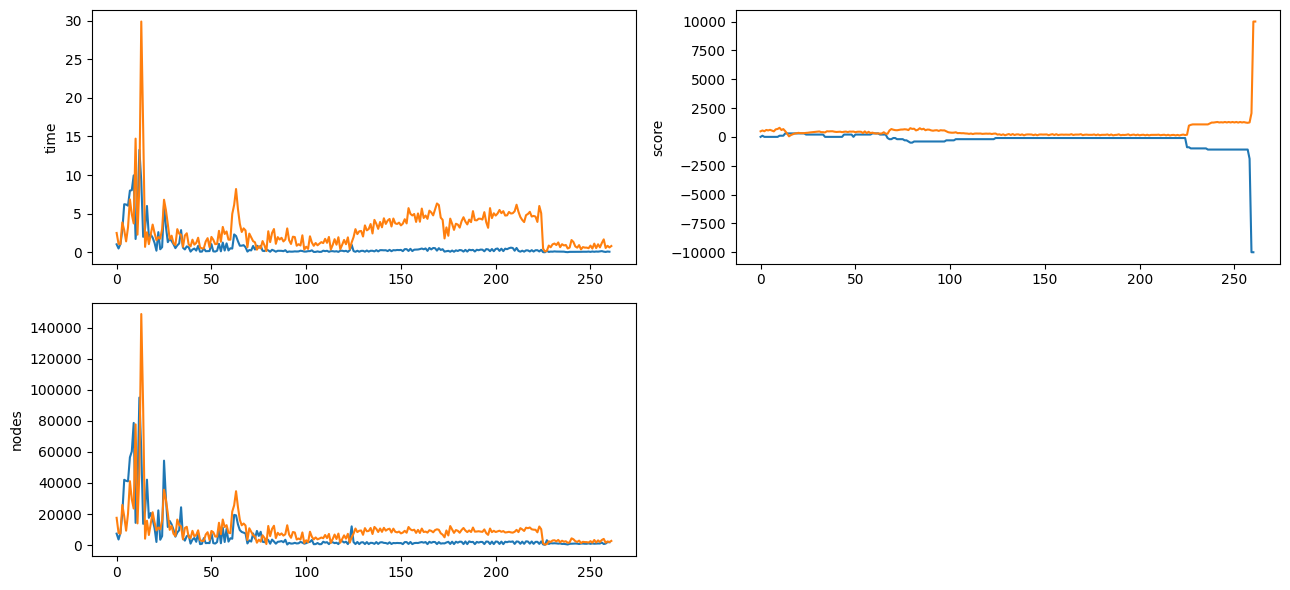

In [69]:
plt.figure(figsize=(13, 6))

plt.subplot(221)
plt.plot(times_1)
plt.plot(times_2)
plt.ylabel('time')

plt.subplot(222)
plt.plot(score_1)
plt.plot(score_2)
plt.ylabel('score')

plt.subplot(223)
plt.plot(nodes_1)
plt.plot(nodes_2)
plt.ylabel('nodes')

plt.tight_layout()
plt.show()

In [67]:
mean_1 = sum(times_1) / len(times_1)
mean_2 = sum(times_2) / len(times_2)
print(sum(times_1), sum(times_2))
print(mean_1, mean_2)

mean_1 = sum(nodes_1) / len(nodes_1)
mean_2 = sum(nodes_2) / len(nodes_2)
print(sum(nodes_1), sum(nodes_2))
print(mean_1, mean_2)

186.00374269999156 761.5828022999958
0.7126580180076305 2.9068045889312817
1442314 2535757
5526.107279693487 9678.461832061068
